In [6]:
# %%
# =====================================
# Verified Synthetic Retraining (1-Round)
# Theoretical Loss vs Real-Data Theoretical Loss
# (X0 fixed; theory computed once per (a, γ); real-data loss constant)
# =====================================

import numpy as np
import math
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm

# --------------------------
# Truncated-normal helper functions
# --------------------------
def phi(x): 
    return 1.0 / np.sqrt(2*np.pi) * np.exp(-x**2 / 2)

def Phi(x): 
    return 0.5 * (1.0 + math.erf(x / np.sqrt(2)))

def C_func(a, b):
    # C(a,b) = (φ(b)-φ(a)) / (Φ(b)-Φ(a))
    denom = Phi(b) - Phi(a)
    return (phi(b) - phi(a)) / denom

def theta_func(a, b):
    r"""
    θ(a,b)
      = 1
        - [b φ(b) - a φ(a)] / [Φ(b) - Φ(a)]
        - { [φ(b) - φ(a)] / [Φ(b) - Φ(a)] }^2
    """
    denom = Phi(b) - Phi(a)
    return 1.0 - (b*phi(b) - a*phi(a))/denom - ((phi(b) - phi(a))/denom)**2

def lambda_func(a, b):
    r"""
    λ(a,b)
     = [ (b^2 - 1)φ(b) - (a^2 - 1)φ(a) ] / [ 2(Φ(b)-Φ(a)) ]
       + [ 3(φ(b)-φ(a)) * (bφ(b) - aφ(a)) ] / [ 2(Φ(b)-Φ(a))^2 ]
       + [ (φ(b)-φ(a))^3 ] / [ (Φ(b)-Φ(a))^3 ].
    """
    denom  = Phi(b) - Phi(a)
    denom2 = denom**2
    denom3 = denom**3
    part1 = ((b**2 - 1.0)*phi(b) - ((a**2) - 1.0)*phi(a)) / (2.0*denom)
    part2 = (3.0*(phi(b)-phi(a))*(b*phi(b) - a*phi(a))) / (2.0*denom2)
    part3 = ((phi(b)-phi(a))**3) / denom3
    return part1 + part2 + part3

# Map to theorem notation: m1 = -C, m2 = θ, m3 = λ
def m1_m2_m3(alpha, beta):
    m1 = -C_func(alpha, beta)
    m2 =  theta_func(alpha, beta)
    m3 = lambda_func(alpha, beta)
    return m1, m2, m3

def _safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def build_alpha_beta_per_direction(V, theta_star, theta_center, r, sigma, sigma_c=1):
    """
    alpha_j = (-r - sigma_c + v_j^T (theta_c - theta*)) / sigma
    beta_j  = ( r + sigma_c + v_j^T (theta_c - theta*)) / sigma
    """
    d = V.shape[1]
    delta = (theta_center - theta_star).reshape(-1)
    proj = V.T @ delta  # (d,)
    alpha = _safe_div(-r - sigma_c + proj, sigma)
    beta  = _safe_div( r + sigma_c + proj, sigma)
    return alpha, beta

# ---- Theorem 3.1 retraining theoretical loss ----
def theoretical_loss_per_direction(alpha_j, beta_j, sigma, n2, mu_j):
    """
    E[(θ̂_{1,proj,j} - v_j^T θ*)^2]
      ≈ σ^2 * [ m2/n2 + m1**2+( m2**2 + m3*m1)/μ_j^2 ]
    """
    m1, m2, m3 = m1_m2_m3(alpha_j, beta_j)
    return sigma**2 * ( m2 / n2 + m1**2 + ( m2**2 + m3*m1) / (mu_j**2) )

def theoretical_total_loss_from_X0(X0, theta_star, theta_center, r, sigma, sigma_c=0.0):
    """
    Sum_j of the leading-order directional losses (Theorem 3.1).
    Returns (total, per_dir, (alpha, beta, mu, V))
    """
    n1, d = X0.shape
    U, s, Vt = np.linalg.svd(X0, full_matrices=False)  # s = μ_j, Vt = V^T
    V = Vt.T
    mu = s
    alpha, beta = build_alpha_beta_per_direction(
        V, theta_star[:d], theta_center[:d], r=r, sigma=sigma, sigma_c=sigma_c
    )
    per_dir = np.array([
        theoretical_loss_per_direction(alpha[j], beta[j], sigma, n2, mu[j])
        for j in range(d)
    ], dtype=float)
    total = float(np.sum(per_dir))
    return total, per_dir, (alpha, beta, mu, V)

# ---- Real-data theoretical loss (baseline): σ² ∑ μ_j^{-2} ----
def theoretical_real_loss_from_X0(X0, sigma):
    _, s, _ = np.linalg.svd(X0, full_matrices=False)
    mu = s
    return sigma**2 * np.sum(1.0 / (mu**2)), mu

# --------------------------
# Grid + single-theory evaluation per (a, γ), with FIXED X0
# --------------------------
np.random.seed(0)
d = 1
sigma = 1.0
n1 = 100  # real-data sample size
n_bias = 300
n_width = 300
n2 = 100  # retrain sample size
bias_vals  = np.linspace(0, 0.7, n_bias)      # a = ||θ* - θ_c||
width_vals = np.linspace(0.01, 0.5, n_width)   # γ = verifier width

# Single global direction u for the whole grid
rng_dir = np.random.default_rng(777)
#u = rng_dir.normal(size=d)
#u = u / np.linalg.norm(u)
#u = (-0.32112345,  0.02597075, -0.4739756 , -0.60003962,  0.23963805,
#       -0.17795991,  0.44972197,  0.14198192)
u=1
# FIXED real-data design X0 for the whole grid (so baseline is constant)
rng_x0 = np.random.default_rng(12345)
X0_fixed = rng_x0.normal(size=(n1, d))

# Compute baseline once (constant across grid)
theta_star = np.ones(d)
real_baseline_total, mu_fixed = theoretical_real_loss_from_X0(X0_fixed, sigma)

# Allocate arrays
theory_retrain_all = np.zeros((n_bias, n_width))
theory_real_all    = np.full((n_bias, n_width), real_baseline_total)  # constant matrix

def compute_entry_once(i, j, bias, width, X0, theta_star, sigma, global_u):
    theta_center = theta_star + bias * (global_u / np.linalg.norm(global_u))
    theory_retrain_total, _, _ = theoretical_total_loss_from_X0(
        X0, theta_star, theta_center, r=width, sigma=sigma
    )
    return i, j, theory_retrain_total

# Evaluate grid (parallelized)
results = Parallel(n_jobs=-1)(
    delayed(compute_entry_once)(i, j, bias_vals[i], width_vals[j],
                                X0_fixed, theta_star, sigma, u)
    for i in range(n_bias) for j in range(n_width)
)

for i, j, l_th_retrain in results:
    theory_retrain_all[i, j] = l_th_retrain

print("Done. (Fixed X0; real-data baseline constant across (a, γ).)")
print("Real-data baseline (scalar):", real_baseline_total)

Done. (Fixed X0; real-data baseline constant across (a, γ).)
Real-data baseline (scalar): 0.011297822189070031


[OK] Saved figure to: /Users/qiyuanliu/Desktop/model_collapse/theory/fig_theoretical_loss_vs_real_loss.png


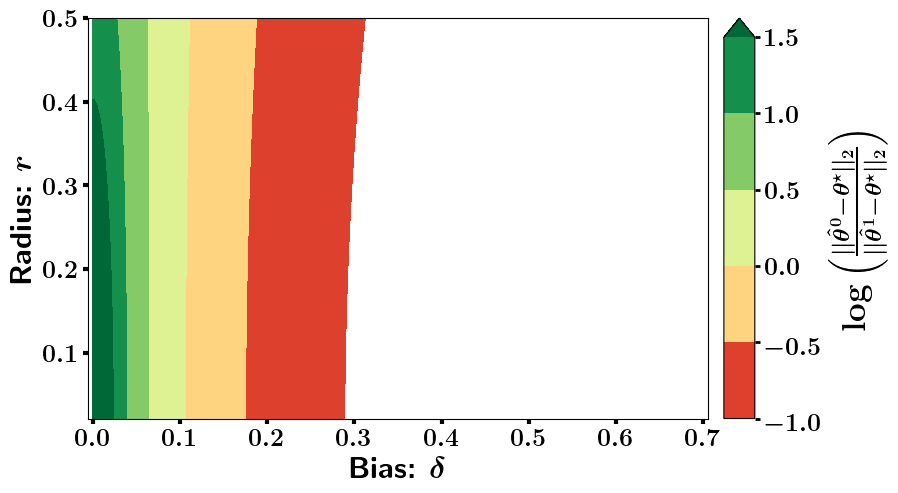

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

# ============================================================
# Compute log improvement: log(real baseline / retrain loss)
# ============================================================
# Compute log improvement: log(real baseline / retrain loss)
# ============================================================
eps = 0
log_imp = 0.5*np.log((theory_real_all + eps) / (theory_retrain_all + eps)).T  # shape (n_width, n_bias)

# ============================================================
# (Optional) Cut small radius region
# ============================================================
radius_min = 0.02
width_mask = width_vals >= radius_min
width_vals_cut = width_vals[width_mask]
log_imp = log_imp[width_mask, :]

# ============================================================
# Matplotlib styling (exact same as your reference)
# ============================================================
plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2
plt.rcParams["text.latex.preamble"] = r"\usepackage{bm}\boldmath"

# ============================================================
# Color normalization and levels
# ============================================================
vmin, vmax = -1, 1.5
levels = [ -1, -0.5, 0, 0.5, 1, 1.5]
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cmap = 'RdYlGn'

# ============================================================
# Figure: single plot + colorbar
# ============================================================
fig = plt.figure(figsize=(8.6, 5.2))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 0.05], wspace=0.05)
ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

cf = ax.contourf(
    bias_vals, width_vals_cut, log_imp,
    levels=levels, cmap=cmap, norm=norm,extend ='max' #extend='both'  # ← 关键
)

ax.set_xlim(bias_vals.min() - 0.005, bias_vals.max() + 0.005)
ax.set_ylim(width_vals_cut.min(), width_vals_cut.max())
ax.set_xlabel(r'\textbf{Bias:} $\mathbf{\delta}$', fontsize=22, fontweight='bold')
ax.set_ylabel(r'\textbf{Radius:} $r$', fontsize=22, fontweight='bold')

# ticks style
ax.tick_params(axis='both', labelsize=18, width=3)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(18)

# colorbar
cbar = fig.colorbar(cf, cax=cax)
cbar.set_label(
    r'$\mathbf{\log \left( \frac{||\hat{\theta}^0-\theta^{\star}||_2}{||\hat{\theta}^1-\theta^{\star}||_2} \right)}$',
    fontsize=24, fontweight='bold'
)
cbar.ax.tick_params(labelsize=18, width=2)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(18)

# ============================================================
# Save/show
# ============================================================
prefix = "/Users/qiyuanliu/Desktop/model_collapse/theory"
os.makedirs(prefix, exist_ok=True)
out_png = os.path.join(prefix, "fig_theoretical_loss_vs_real_loss.png")
fig.savefig(out_png, bbox_inches='tight', dpi=600)
print(f"[OK] Saved figure to: {out_png}")
plt.show()
